## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

## 2. Load Dataset

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Exploratory Data Analysis

In [3]:
# Dataset overview
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nDataset information:")
df.info()

Dataset shape: (12330, 18)

Column names:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  

In [4]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values)

Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [5]:
# Check target variable distribution
revenue_counts = df["Revenue"].value_counts()
revenue_percent = df["Revenue"].value_counts(normalize=True)

print("Revenue counts:")
print(revenue_counts)
print("\nRevenue percentage:")
print(revenue_percent)

Revenue counts:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Revenue percentage:
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


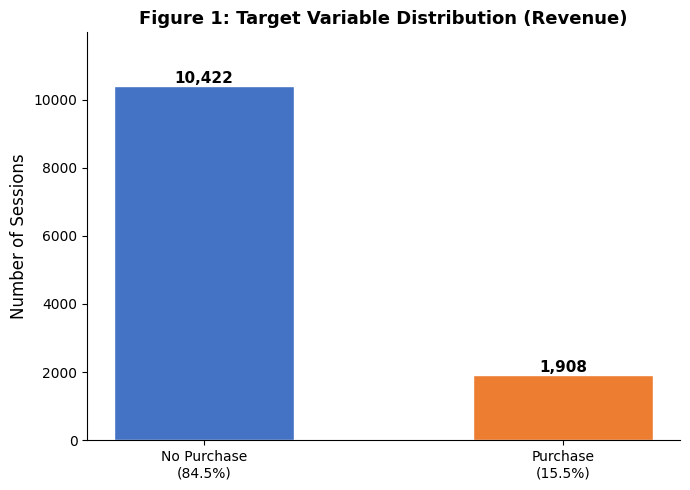

Saved: fig1_class_distribution.png


In [6]:
# Figure 1: Class distribution (report)
n_neg = revenue_counts[False] if False in revenue_counts.index else revenue_counts[0]
n_pos = revenue_counts[True]  if True  in revenue_counts.index else revenue_counts[1]
pct_neg = n_neg / len(df) * 100
pct_pos = n_pos / len(df) * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(
    [f"No Purchase\n({pct_neg:.1f}%)", f"Purchase\n({pct_pos:.1f}%)"],
    [n_neg, n_pos],
    color=["#4472C4", "#ED7D31"], edgecolor="white", width=0.5
)
for bar, val in zip(bars, [n_neg, n_pos]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f"{val:,}", ha="center", fontsize=11, fontweight="bold")
plt.ylabel("Number of Sessions", fontsize=12)
plt.title("Figure 1: Target Variable Distribution (Revenue)", fontsize=13, fontweight="bold")
plt.ylim(0, n_neg * 1.15)
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_class_distribution.png")

In [7]:
# Convert boolean variables into numeric values
df["Revenue"] = df["Revenue"].astype(int)
df["Weekend"] = df["Weekend"].astype(int)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


In [8]:
# Correlation analysis with Revenue
corr = df.corr(numeric_only=True)
revenue_corr = corr["Revenue"].drop("Revenue").sort_values(ascending=False)
revenue_corr

,Revenue
PageValues,0.492569
ProductRelated,0.158538
ProductRelated_Duration,0.152373
Administrative,0.138917
Informational,0.095200
Administrative_Duration,0.093587
Informational_Duration,0.070345
Weekend,0.029295
Browser,0.023984
TrafficType,-0.005113


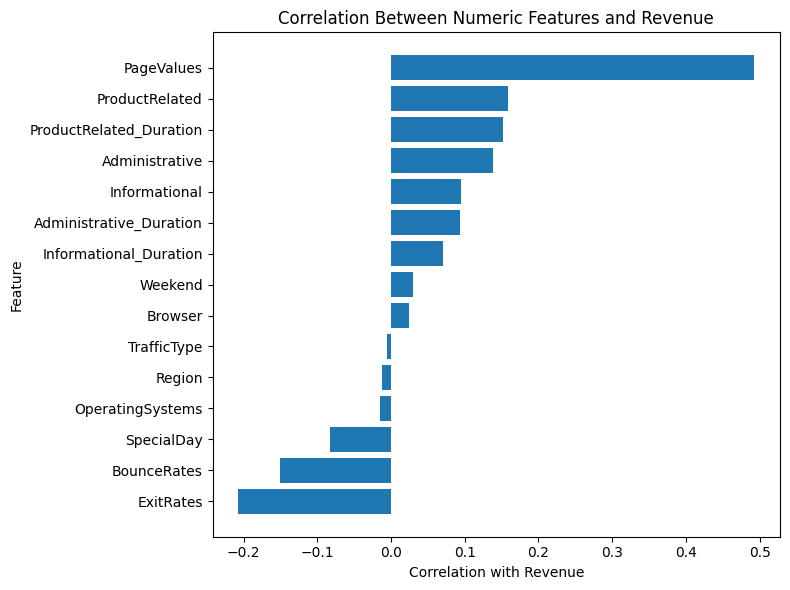

In [9]:
# Plot correlation between numeric features and Revenue
revenue_corr_sorted = revenue_corr.sort_values()

plt.figure(figsize=(8, 6))
plt.barh(revenue_corr_sorted.index, revenue_corr_sorted.values)
plt.xlabel("Correlation with Revenue")
plt.ylabel("Feature")
plt.title("Correlation Between Numeric Features and Revenue")
plt.tight_layout()
plt.show()

/tmp/ipykernel_472/276114594.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


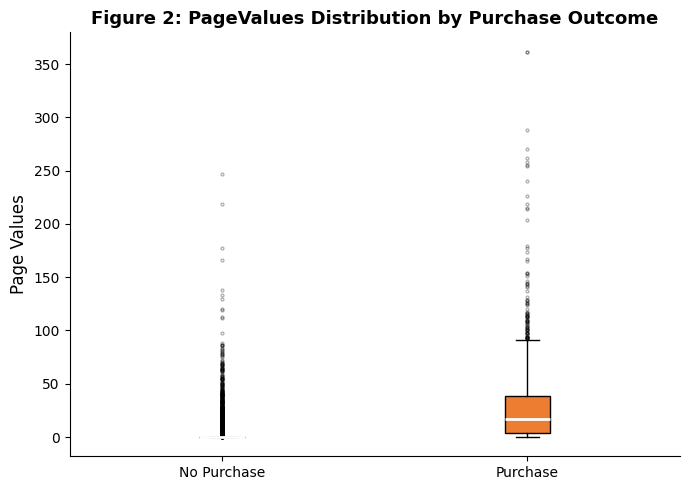

Saved: fig2_pagevalues_boxplot.png


In [10]:
# Figure 2: PageValues by purchase outcome — boxplot (report)
plt.figure(figsize=(7, 5))
bp = plt.boxplot(
    [df[df["Revenue"]==0]["PageValues"], df[df["Revenue"]==1]["PageValues"]],
    labels=["No Purchase", "Purchase"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.3)
)
bp["boxes"][0].set_facecolor("#4472C4")
bp["boxes"][1].set_facecolor("#ED7D31")
plt.ylabel("Page Values", fontsize=12)
plt.title("Figure 2: PageValues Distribution by Purchase Outcome", fontsize=13, fontweight="bold")
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig2_pagevalues_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_pagevalues_boxplot.png")

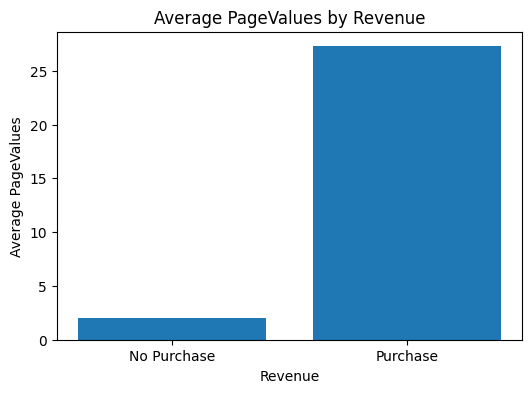

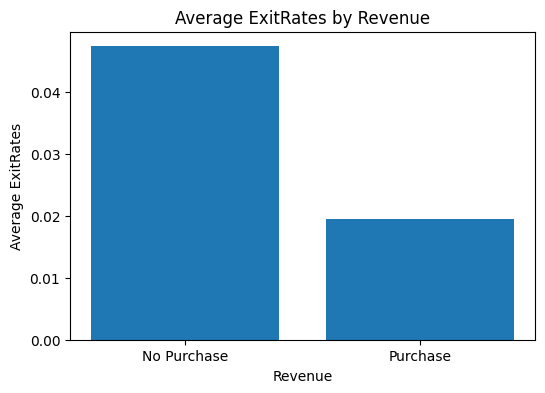

In [11]:
# Compare average PageValues and ExitRates by purchase outcome (original analysis)
key_features = ["PageValues", "ExitRates"]

for feature in key_features:
    avg_values = df.groupby("Revenue")[feature].mean()

    plt.figure(figsize=(6, 4))
    plt.bar(["No Purchase", "Purchase"], avg_values.values)
    plt.xlabel("Revenue")
    plt.ylabel("Average " + feature)
    plt.title("Average " + feature + " by Revenue")
    plt.show()

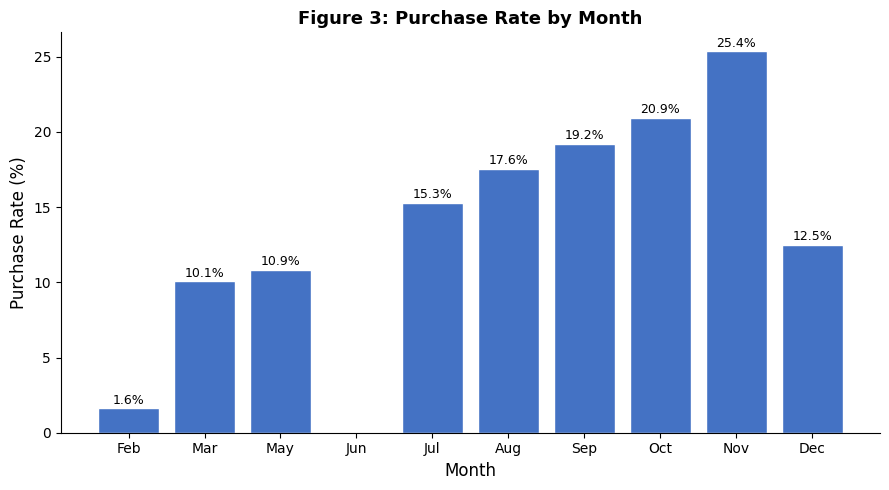

Saved: fig3_month_purchase_rate.png


In [12]:
# Figure 3: Purchase rate by month (report)
month_order = ["Feb", "Mar", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_stats = df.groupby("Month")["Revenue"].mean().reindex(month_order) * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(month_stats.index, month_stats.values, color="#4472C4", edgecolor="white")
for bar, val in zip(bars, month_stats.values):
    if not pd.isna(val):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=9)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Purchase Rate (%)", fontsize=12)
plt.title("Figure 3: Purchase Rate by Month", fontsize=13, fontweight="bold")
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig3_month_purchase_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_month_purchase_rate.png")

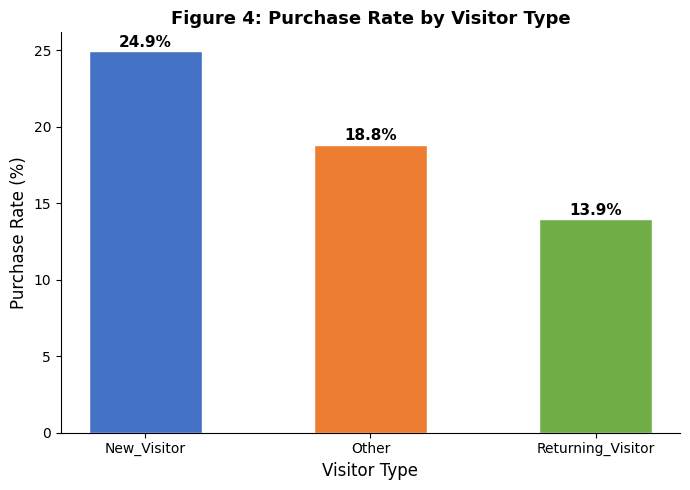

Saved: fig4_visitor_type.png


In [13]:
# Figure 4: Purchase rate by visitor type (report)
visitor_stats = df.groupby("VisitorType")["Revenue"].mean() * 100
colors_v = ["#4472C4", "#ED7D31", "#70AD47"]

plt.figure(figsize=(7, 5))
bars = plt.bar(visitor_stats.index, visitor_stats.values,
               color=colors_v[:len(visitor_stats)], edgecolor="white", width=0.5)
for i, (idx, val) in enumerate(visitor_stats.items()):
    plt.text(i, val + 0.3, f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
plt.xlabel("Visitor Type", fontsize=12)
plt.ylabel("Purchase Rate (%)", fontsize=12)
plt.title("Figure 4: Purchase Rate by Visitor Type", fontsize=13, fontweight="bold")
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig4_visitor_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_visitor_type.png")

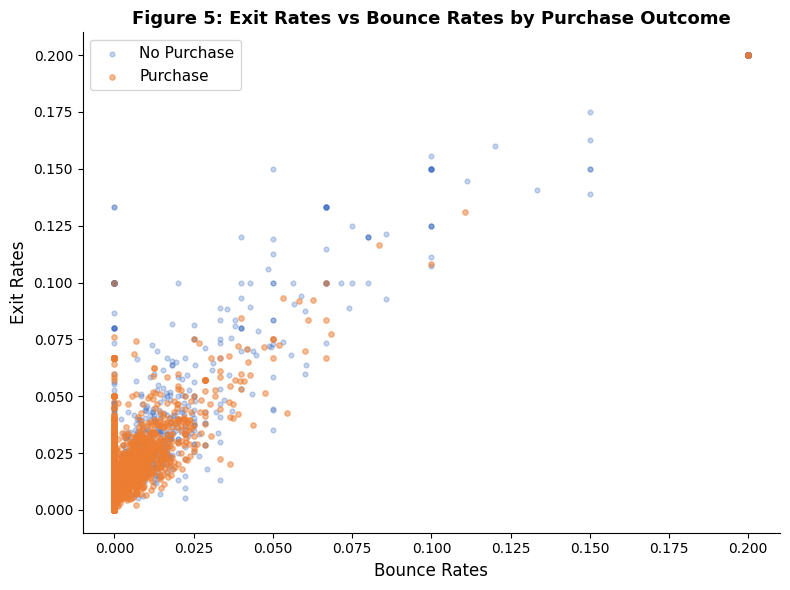

Saved: fig5_scatter_exit_bounce.png


In [14]:
# Figure 5: Exit Rates vs Bounce Rates scatter (report)
no_p  = df[df["Revenue"]==0].sample(min(1000, (df["Revenue"]==0).sum()), random_state=42)
yes_p = df[df["Revenue"]==1]

plt.figure(figsize=(8, 6))
plt.scatter(no_p["BounceRates"],  no_p["ExitRates"],  alpha=0.3, s=12, color="#4472C4", label="No Purchase")
plt.scatter(yes_p["BounceRates"], yes_p["ExitRates"], alpha=0.5, s=15, color="#ED7D31", label="Purchase")
plt.xlabel("Bounce Rates", fontsize=12)
plt.ylabel("Exit Rates", fontsize=12)
plt.title("Figure 5: Exit Rates vs Bounce Rates by Purchase Outcome", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_scatter_exit_bounce.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_scatter_exit_bounce.png")

## 4. Data Preprocessing

In [15]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=["Month", "VisitorType"],
    drop_first=True
)
df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


### Save Cleaned Modeling Data

The file below is the cleaned dataset used for modeling. It includes numeric target values and one-hot encoded categorical variables.

In [16]:
# Export cleaned / processed dataset used for modeling
cleaned_data = df_encoded.copy()
cleaned_data.to_csv("cleaned_data.csv", index=False)

print("Saved: cleaned_data.csv")
print("Cleaned data shape:", cleaned_data.shape)
cleaned_data.head()

Saved: cleaned_data.csv
Cleaned data shape: (12330, 27)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [17]:
# Separate features and target variable
X = df_encoded.drop("Revenue", axis=1)
y = df_encoded["Revenue"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (12330, 26)
Target shape: (12330,)


In [18]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (8631, 26)
Testing set: (3699, 26)

Training target distribution:
Revenue
0    0.845209
1    0.154791
Name: proportion, dtype: float64

Testing target distribution:
Revenue
0    0.845364
1    0.154636
Name: proportion, dtype: float64


In [19]:
# Standardize features for Logistic Regression, KNN, and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Handle Class Imbalance with SMOTE

SMOTE is applied **only on the training set** to avoid data leakage.

In [20]:
# Apply SMOTE on training set only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 7295, 1: 1336}
After SMOTE:  {0: 7295, 1: 7295}


In [21]:
# Scale SMOTE-resampled data (for LR, KNN, SVM)
X_train_sm_scaled = scaler.fit_transform(X_train_sm)

## 6. Model Training

Each model is trained twice: on the **original** training set and on the **SMOTE-resampled** set.

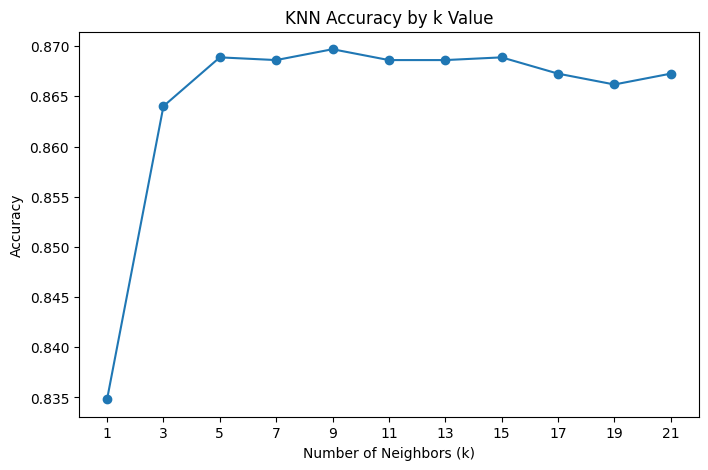

Best k: 9


In [22]:
# Tune KNN using different k values (on original training set)
k_values = list(range(1, 22, 2))
knn_accuracy = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    pred_temp = knn_temp.predict(X_test_scaled)
    knn_accuracy.append(accuracy_score(y_test, pred_temp))

knn_tuning = pd.DataFrame({"k": k_values, "Accuracy": knn_accuracy})

plt.figure(figsize=(8, 5))
plt.plot(knn_tuning["k"], knn_tuning["Accuracy"], marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy by k Value")
plt.xticks(k_values)
plt.show()

best_k = int(knn_tuning.sort_values(by="Accuracy", ascending=False).iloc[0]["k"])
print("Best k:", best_k)

In [23]:
# --- Original training set models ---

# Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# KNN
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# SVM
svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced")
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

# XGBoost
ratio = int(y_train.value_counts()[0] / y_train.value_counts()[1])
xgb_model = XGBClassifier(n_estimators=200, scale_pos_weight=ratio, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("All original models trained.")

All original models trained.


In [24]:
# --- SMOTE training set models ---

# Logistic Regression (SMOTE)
log_sm_model = LogisticRegression(max_iter=1000)
log_sm_model.fit(X_train_sm_scaled, y_train_sm)
log_sm_pred = log_sm_model.predict(X_test_scaled)
log_sm_prob = log_sm_model.predict_proba(X_test_scaled)[:, 1]

# KNN (SMOTE)
knn_sm_model = KNeighborsClassifier(n_neighbors=best_k)
knn_sm_model.fit(X_train_sm_scaled, y_train_sm)
knn_sm_pred = knn_sm_model.predict(X_test_scaled)
knn_sm_prob = knn_sm_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest (SMOTE)
rf_sm_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_sm_model.fit(X_train_sm, y_train_sm)
rf_sm_pred = rf_sm_model.predict(X_test)
rf_sm_prob = rf_sm_model.predict_proba(X_test)[:, 1]

# SVM (SMOTE)
svm_sm_model = SVC(kernel="rbf", probability=True)
svm_sm_model.fit(X_train_sm_scaled, y_train_sm)
svm_sm_pred = svm_sm_model.predict(X_test_scaled)
svm_sm_prob = svm_sm_model.predict_proba(X_test_scaled)[:, 1]

# XGBoost (SMOTE)
xgb_sm_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss")
xgb_sm_model.fit(X_train_sm, y_train_sm)
xgb_sm_pred = xgb_sm_model.predict(X_test)
xgb_sm_prob = xgb_sm_model.predict_proba(X_test)[:, 1]

print("All SMOTE models trained.")

All SMOTE models trained.


## 7. Model Evaluation

In [25]:
# Confusion matrix and classification report for all original models
models_orig = {
    "Logistic Regression": log_pred,
    "KNN": knn_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "XGBoost": xgb_pred
}

for model_name, prediction in models_orig.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Accuracy:", round(accuracy_score(y_test, prediction), 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, prediction))
    print("\nClassification Report:")
    print(classification_report(y_test, prediction))

Logistic Regression
Accuracy: 0.8529

Confusion Matrix:
[[2727  400]
 [ 144  428]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      3127
           1       0.52      0.75      0.61       572

    accuracy                           0.85      3699
   macro avg       0.73      0.81      0.76      3699
weighted avg       0.88      0.85      0.86      3699

KNN
Accuracy: 0.8697

Confusion Matrix:
[[3040   87]
 [ 395  177]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3127
           1       0.67      0.31      0.42       572

    accuracy                           0.87      3699
   macro avg       0.78      0.64      0.67      3699
weighted avg       0.85      0.87      0.85      3699

Random Forest
Accuracy: 0.8989

Confusion Matrix:
[[3028   99]
 [ 275  297]]

Classification Report:
              precision    recall  f1-score   s

## 8. Model Comparison

In [26]:
def build_results(names, preds, probs):
    return pd.DataFrame({
        "Model": names,
        "Accuracy": [accuracy_score(y_test, p) for p in preds],
        "Precision": [precision_score(y_test, p) for p in preds],
        "Recall": [recall_score(y_test, p) for p in preds],
        "F1": [f1_score(y_test, p) for p in preds],
        "AUC": [roc_auc_score(y_test, pb) for pb in probs]
    }).round(4)

orig_names = ["LR", "KNN", "RF", "SVM", "XGBoost"]
orig_preds = [log_pred, knn_pred, rf_pred, svm_pred, xgb_pred]
orig_probs = [log_prob, knn_prob, rf_prob, svm_prob, xgb_prob]

sm_names = ["LR (SMOTE)", "KNN (SMOTE)", "RF (SMOTE)", "SVM (SMOTE)", "XGBoost (SMOTE)"]
sm_preds = [log_sm_pred, knn_sm_pred, rf_sm_pred, svm_sm_pred, xgb_sm_pred]
sm_probs = [log_sm_prob, knn_sm_prob, rf_sm_prob, svm_sm_prob, xgb_sm_prob]

results_orig = build_results(orig_names, orig_preds, orig_probs)
results_sm   = build_results(sm_names, sm_preds, sm_probs)

all_results = pd.concat([results_orig, results_sm], ignore_index=True)
all_results

,Model,Accuracy,Precision,Recall,F1,AUC
0,LR,0.8529,0.5169,0.7483,0.6114,0.9005
1,KNN,0.8697,0.6705,0.3094,0.4234,0.8093
2,RF,0.8989,0.7500,0.5192,0.6136,0.9200
3,SVM,0.8616,0.5377,0.7483,0.6257,0.8859
4,XGBoost,0.8897,0.6449,0.6381,0.6415,0.9143
5,LR (SMOTE),0.5596,0.2541,0.9545,0.4013,0.8732
6,KNN (SMOTE),0.8143,0.4326,0.6451,0.5179,0.8227
7,RF (SMOTE),0.8856,0.6155,0.6941,0.6524,0.9202
8,SVM (SMOTE),0.6042,0.2643,0.8741,0.4058,0.8416
9,XGBoost (SMOTE),0.8900,0.6377,0.6678,0.6524,0.9144


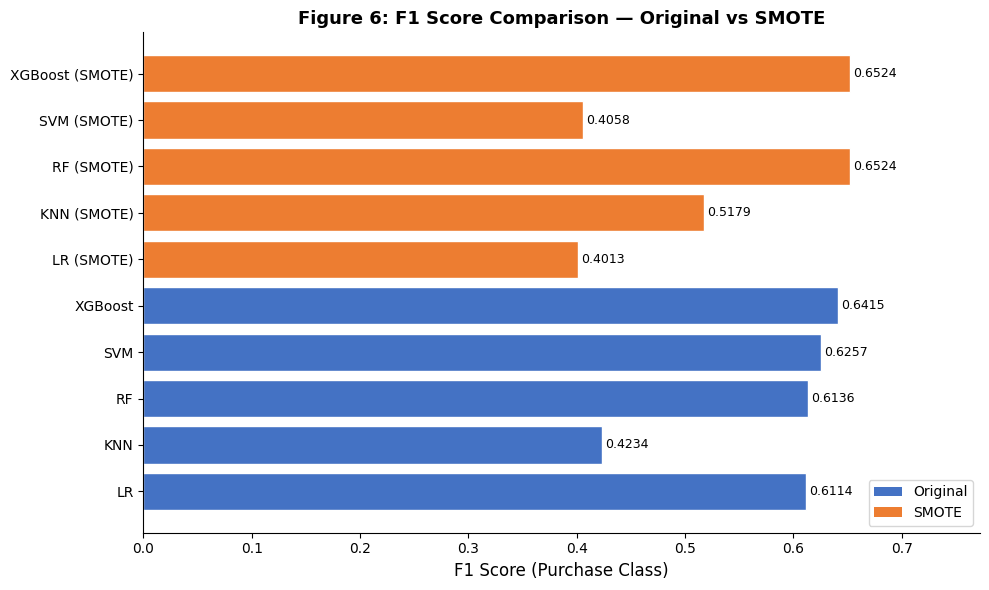

Saved: fig6_f1_comparison.png


In [27]:
# Figure 6: F1 score comparison (report)
from matplotlib.patches import Patch

colors_bar = ["#4472C4"] * 5 + ["#ED7D31"] * 5
legend_h = [Patch(facecolor="#4472C4", label="Original"), Patch(facecolor="#ED7D31", label="SMOTE")]

plt.figure(figsize=(10, 6))
bars = plt.barh(all_results["Model"], all_results["F1"], color=colors_bar, edgecolor="white")
for i, val in enumerate(all_results["F1"]):
    plt.text(val + 0.003, i, f"{val:.4f}", va="center", fontsize=9)
plt.xlabel("F1 Score (Purchase Class)", fontsize=12)
plt.title("Figure 6: F1 Score Comparison — Original vs SMOTE", fontsize=13, fontweight="bold")
plt.legend(handles=legend_h, fontsize=10)
plt.xlim(0, all_results["F1"].max() + 0.12)
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig6_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig6_f1_comparison.png")

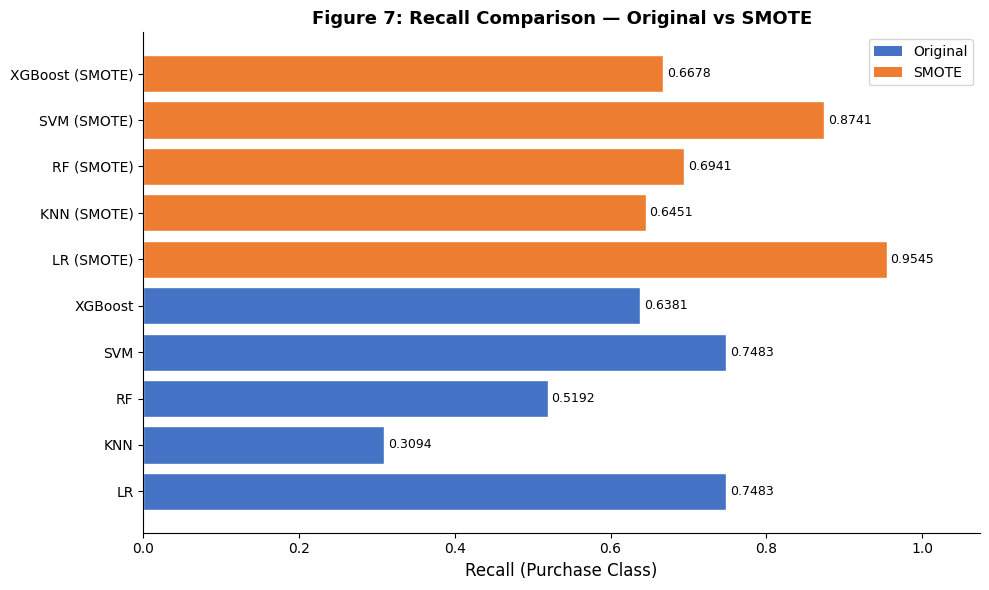

Saved: fig7_recall_comparison.png


In [28]:
# Figure 7: Recall comparison (report)
plt.figure(figsize=(10, 6))
bars = plt.barh(all_results["Model"], all_results["Recall"], color=colors_bar, edgecolor="white")
for i, val in enumerate(all_results["Recall"]):
    plt.text(val + 0.005, i, f"{val:.4f}", va="center", fontsize=9)
plt.xlabel("Recall (Purchase Class)", fontsize=12)
plt.title("Figure 7: Recall Comparison — Original vs SMOTE", fontsize=13, fontweight="bold")
plt.legend(handles=legend_h, fontsize=10)
plt.xlim(0, all_results["Recall"].max() + 0.12)
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig7_recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig7_recall_comparison.png")

## 9. ROC Curve Comparison

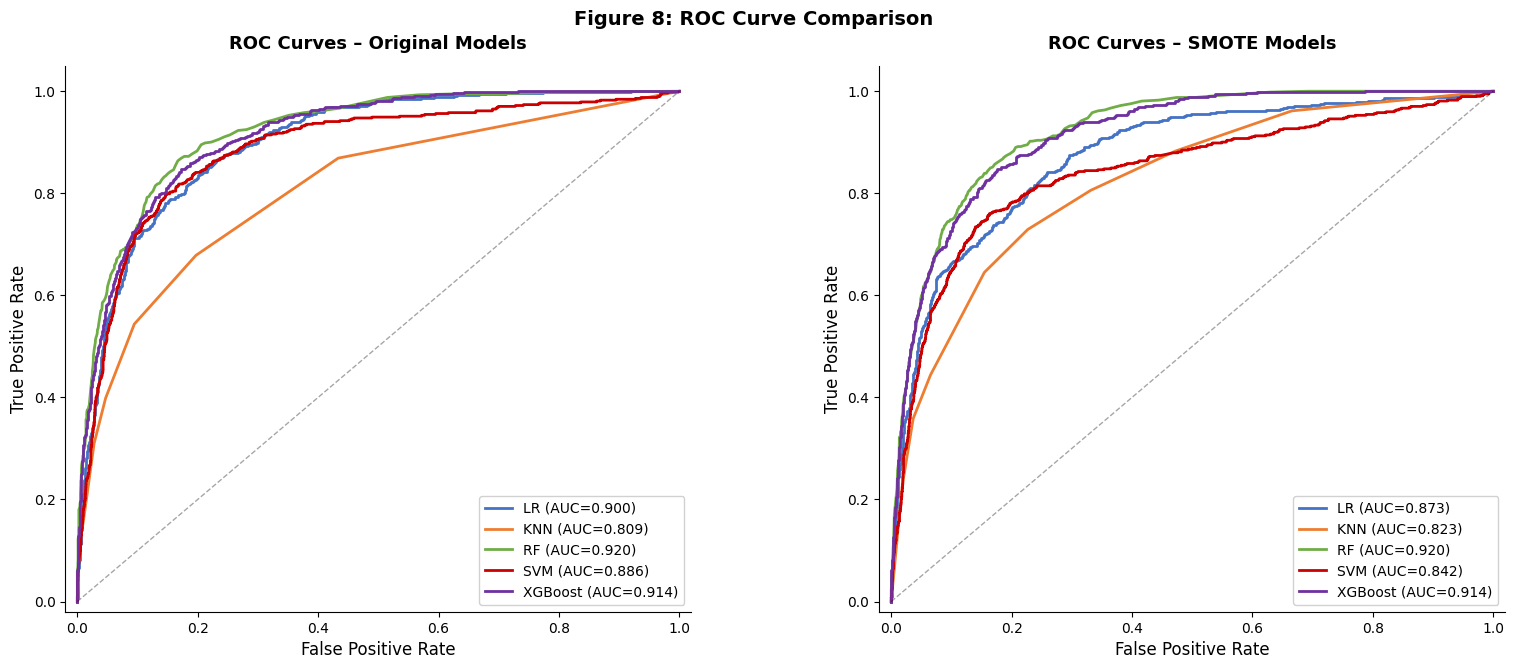

Saved: fig8_roc_curves.png


In [29]:
# Figure 8: ROC curves — both panels side by side (report)
roc_colors = ["#4472C4", "#ED7D31", "#70AD47", "#CC0000", "#7030A0"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.subplots_adjust(left=0.07, right=0.97, top=0.90, bottom=0.12, wspace=0.30)

for ax, names, probs, title in [
    (axes[0], orig_names, orig_probs, "Original Models"),
    (axes[1], sm_names,   sm_probs,   "SMOTE Models"),
]:
    for name, prob, color in zip(names, probs, roc_colors):
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        short = name.replace(" (SMOTE)", "")
        ax.plot(fpr, tpr, label=f"{short} (AUC={auc:.3f})", color=color, linewidth=2)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.35, linewidth=1)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"ROC Curves – {title}", fontsize=13, fontweight="bold", pad=12)
    ax.legend(fontsize=10, loc="lower right", framealpha=0.9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Figure 8: ROC Curve Comparison", fontsize=14, fontweight="bold", y=0.98)
plt.savefig("fig8_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig8_roc_curves.png")

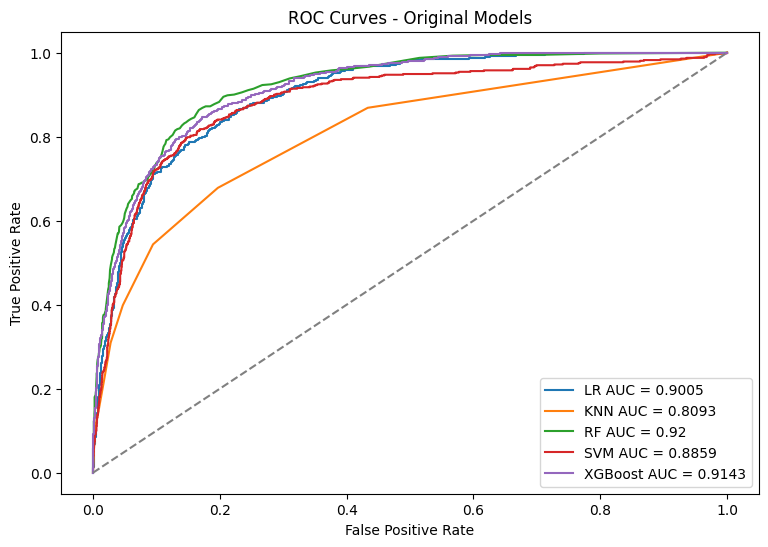

In [30]:
# ROC curves: Original models (individual — original style)
plt.figure(figsize=(9, 6))
for name, prob in zip(orig_names, orig_probs):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=name + " AUC = " + str(round(auc, 4)))

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Original Models")
plt.legend()
plt.show()

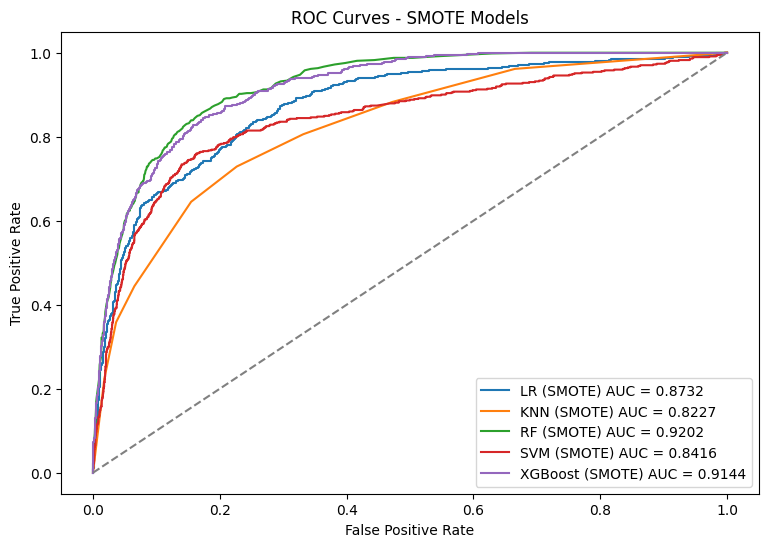

In [31]:
# ROC curves: SMOTE models (individual — original style)
plt.figure(figsize=(9, 6))
for name, prob in zip(sm_names, sm_probs):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=name + " AUC = " + str(round(auc, 4)))

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - SMOTE Models")
plt.legend()
plt.show()

## 10. Feature Importance

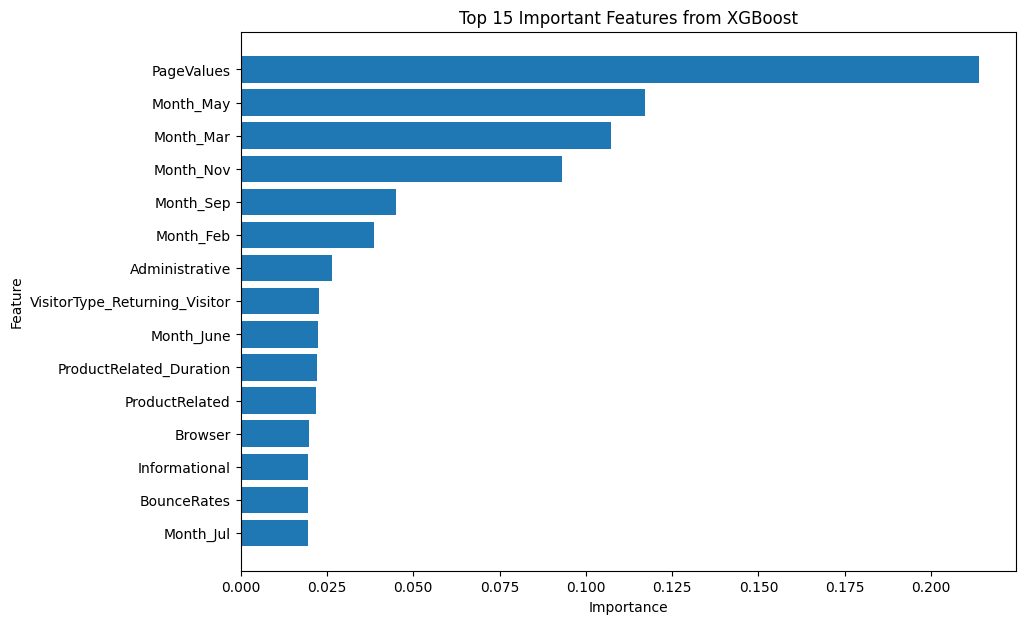

In [32]:
# XGBoost feature importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_xgb = xgb_importance.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_xgb["Feature"], top_xgb["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features from XGBoost")
plt.show()

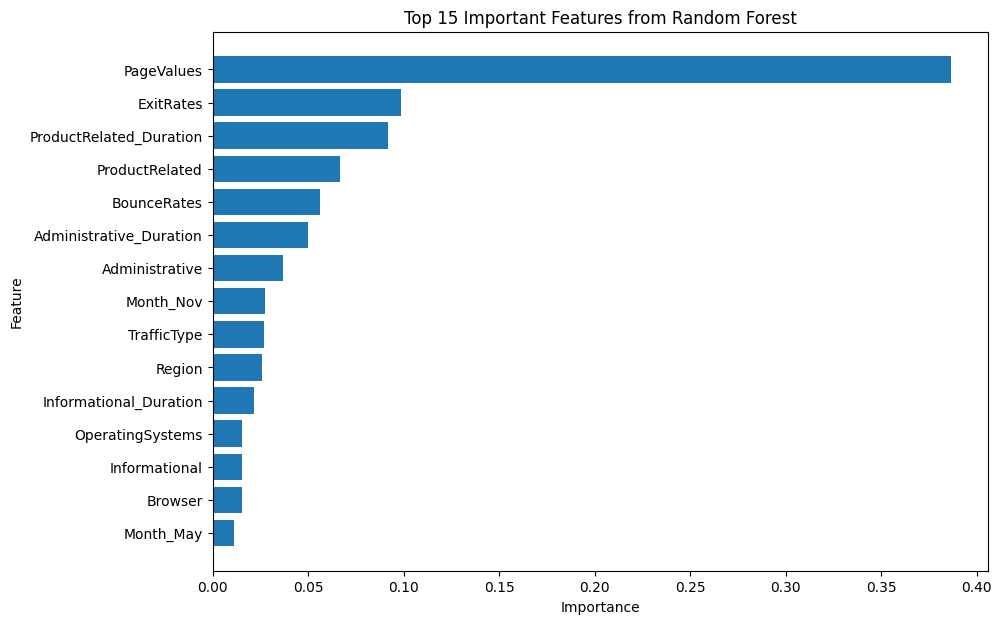

In [33]:
# Random Forest feature importance (for comparison)
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_rf = rf_importance.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_rf["Feature"], top_rf["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features from Random Forest")
plt.show()

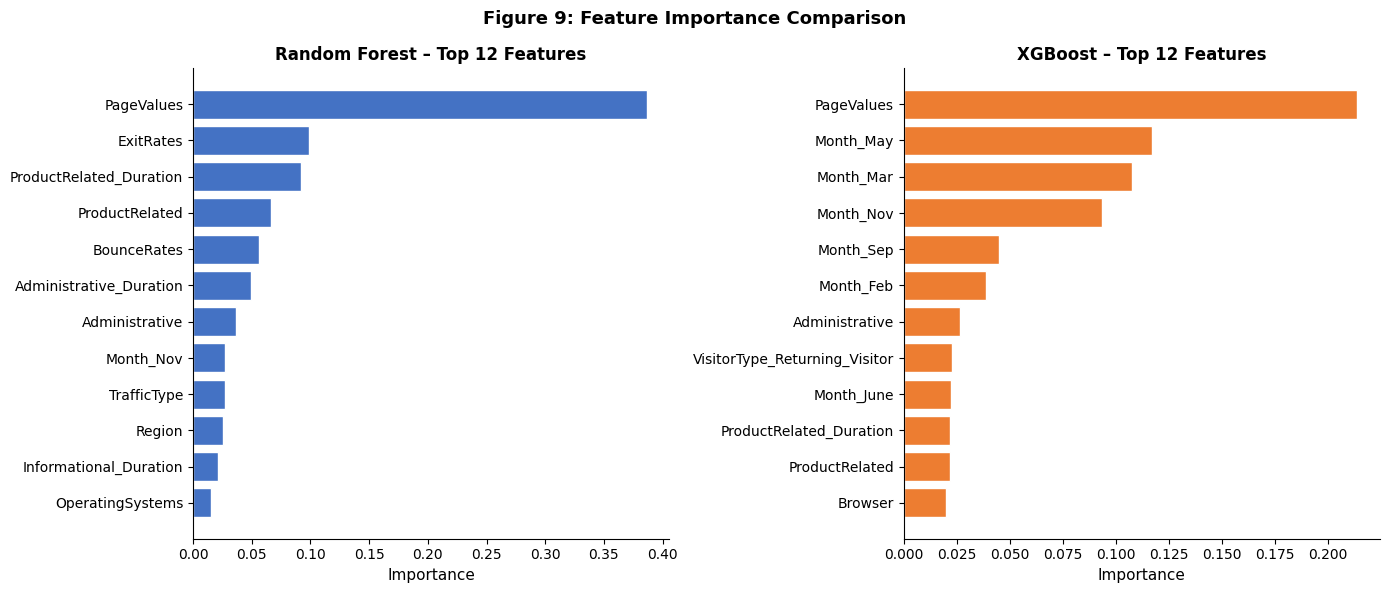

Saved: fig9_feature_importance.png


In [34]:
# Figure 9: Feature importance — RF and XGBoost side by side (report)
rf_top12  = rf_importance.head(12)
xgb_top12 = xgb_importance.head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, imp, title, color in zip(
    axes,
    [rf_top12, xgb_top12],
    ["Random Forest – Top 12 Features", "XGBoost – Top 12 Features"],
    ["#4472C4", "#ED7D31"]
):
    ax.barh(imp["Feature"][::-1], imp["Importance"][::-1], color=color, edgecolor="white")
    ax.set_xlabel("Importance", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Figure 9: Feature Importance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig9_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig9_feature_importance.png")

## 11. Error Analysis (Best Model: XGBoost)

In [35]:
# Error analysis using XGBoost
error_analysis = X_test.copy()
error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = xgb_pred
error_analysis["Predicted_Probability"] = xgb_prob

false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]

print("False negatives (missed purchases):", false_negatives.shape[0])
print("False positives (wrongly predicted purchase):", false_positives.shape[0])

False negatives (missed purchases): 207
False positives (wrongly predicted purchase): 201


In [36]:
# Compare correctly predicted purchases vs missed purchases
correct_purchases = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 1)
]

comparison_features = ["PageValues", "ExitRates", "BounceRates", "ProductRelated_Duration"]

comparison_table = pd.DataFrame({
    "Correct Purchase Prediction": correct_purchases[comparison_features].mean(),
    "Missed Purchase Prediction": false_negatives[comparison_features].mean()
})

comparison_table

,Correct Purchase Prediction,Missed Purchase Prediction
PageValues,36.778997,6.225766
ExitRates,0.017423,0.026819
BounceRates,0.003765,0.009271
ProductRelated_Duration,1848.401352,2147.475168


## 12. Summary

In [37]:
# Best model by F1
best_f1 = all_results.sort_values(by="F1", ascending=False).iloc[0]
print("Best model by F1:")
print(best_f1)
print()

# Best model by AUC
best_auc = all_results.sort_values(by="AUC", ascending=False).iloc[0]
print("Best model by AUC:")
print(best_auc)

Best model by F1:
Model        RF (SMOTE)
Accuracy         0.8856
Precision        0.6155
Recall           0.6941
F1               0.6524
AUC              0.9202
Name: 7, dtype: object

Best model by AUC:
Model        RF (SMOTE)
Accuracy         0.8856
Precision        0.6155
Recall           0.6941
F1               0.6524
AUC              0.9202
Name: 7, dtype: object


## 13. Export Results for Tableau

In [38]:
# Export model comparison results
all_results.to_csv("model_results.csv", index=False)
print("Saved: model_results.csv")

Saved: model_results.csv


In [39]:
# Export feature importance
xgb_importance.to_csv("xgb_feature_importance.csv", index=False)
rf_importance.to_csv("rf_feature_importance.csv", index=False)
print("Saved: xgb_feature_importance.csv")
print("Saved: rf_feature_importance.csv")

Saved: xgb_feature_importance.csv
Saved: rf_feature_importance.csv
